In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

mne.set_log_level('WARNING')
print("MNE version:", mne.__version__)
print("All imports successful")

MNE version: 1.11.0
All imports successful


In [2]:
# load the GDF file
raw = mne.io.read_raw_gdf('../data/A01T.gdf', preload=True)

# print basic info
print(raw.info)
print(f"\nDuration: {raw.times[-1]:.1f} seconds")
print(f"Sampling rate: {raw.info['sfreq']} Hz")
print(f"Number of channels: {len(raw.ch_names)}")
print(f"\nChannel names:")
print(raw.ch_names)

c:\Python314\Lib\contextlib.py:148: RuntimeWarning: Channel names are not unique, found duplicates for: {'EEG'}. Applying running numbers for duplicates.
  next(self.gen)


<Info | 8 non-empty values
 bads: []
 ch_names: EEG-Fz, EEG-0, EEG-1, EEG-2, EEG-3, EEG-4, EEG-5, EEG-C3, EEG-6, ...
 chs: 25 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 100.0 Hz
 meas_date: 2005-01-17 12:00:00 UTC
 nchan: 25
 projs: []
 sfreq: 250.0 Hz
 subject_info: <subject_info | his_id: A01, sex: 0, last_name: X, birthday: 1983-01-17>
>

Duration: 2690.1 seconds
Sampling rate: 250.0 Hz
Number of channels: 25

Channel names:
['EEG-Fz', 'EEG-0', 'EEG-1', 'EEG-2', 'EEG-3', 'EEG-4', 'EEG-5', 'EEG-C3', 'EEG-6', 'EEG-Cz', 'EEG-7', 'EEG-C4', 'EEG-8', 'EEG-9', 'EEG-10', 'EEG-11', 'EEG-12', 'EEG-13', 'EEG-14', 'EEG-Pz', 'EEG-15', 'EEG-16', 'EOG-left', 'EOG-central', 'EOG-right']


In [3]:
# extract events from the recording
events, event_id = mne.events_from_annotations(raw)

print("Event types found:")
for name, code in event_id.items():
    count = np.sum(events[:, 2] == code)
    print(f"  {name}: code {code} — {count} occurrences")

print(f"\nTotal events: {len(events)}")

Event types found:
  1023: code 1 — 15 occurrences
  1072: code 2 — 1 occurrences
  276: code 3 — 1 occurrences
  277: code 4 — 1 occurrences
  32766: code 5 — 9 occurrences
  768: code 6 — 288 occurrences
  769: code 7 — 72 occurrences
  770: code 8 — 72 occurrences
  771: code 9 — 72 occurrences
  772: code 10 — 72 occurrences

Total events: 603


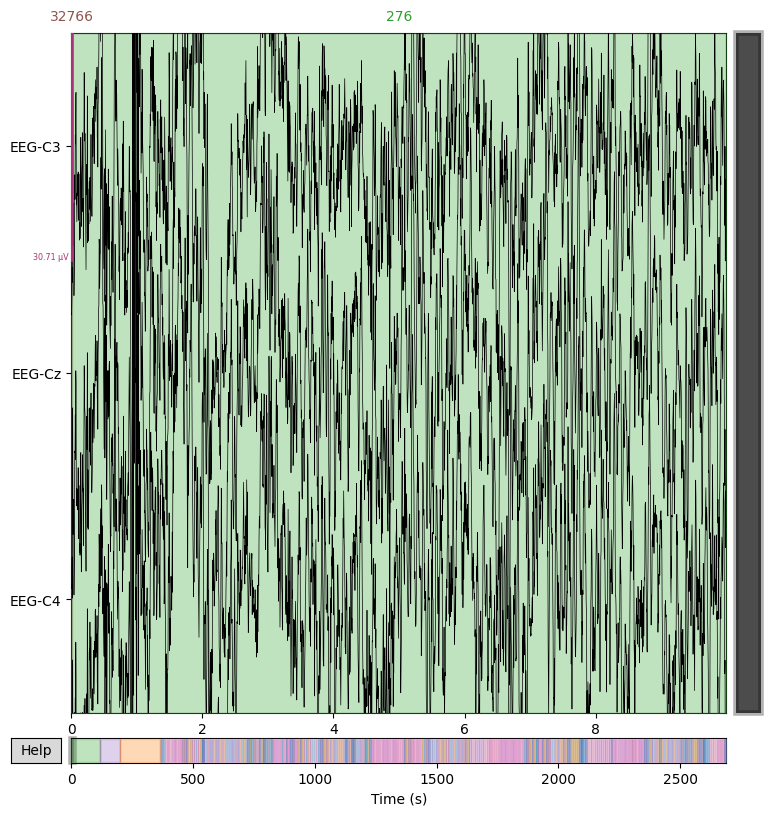

In [4]:
# pick the 3 most important motor cortex channels
picks = ['EEG-C3', 'EEG-Cz', 'EEG-C4']

# plot 10 seconds of raw signal
raw.plot(duration=10, 
         picks=picks,
         scalings='auto',
         title='Raw EEG signal — motor cortex channels',
         show=True)
plt.show()

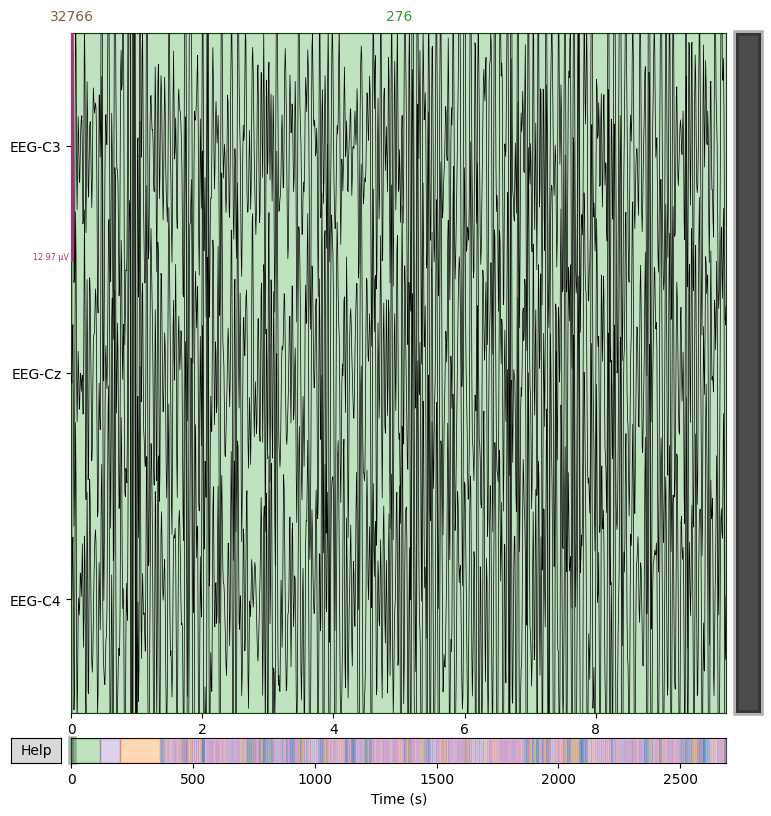

In [5]:
# apply bandpass filter 8-30 Hz
raw_filtered = raw.copy()
raw_filtered.filter(l_freq=8, h_freq=30, 
                    picks='eeg',
                    method='iir')

# plot the same 10 seconds after filtering
raw_filtered.plot(duration=10,
                  picks=picks,
                  scalings='auto',
                  title='Filtered EEG signal — 8-30 Hz (mu and beta rhythms)',
                  show=True)
plt.show()

In [7]:
# define the 4 motor imagery event codes
# using the remapped codes MNE assigned (from Cell 3 output)
event_id_mi = {
    'left_hand':  7,   # original 769
    'right_hand': 8,   # original 770
    'feet':       9,   # original 771
    'tongue':     10   # original 772
}

# extract epochs — 0 to 4 seconds after each trial start
epochs = mne.Epochs(
    raw_filtered,
    events,
    event_id=event_id_mi,
    tmin=0.0,
    tmax=4.0,
    baseline=None,
    preload=True,
    reject=dict(eeg=100e-6)
)

print(epochs)
print(f"\nEpoch shape: {epochs.get_data().shape}")
print(f"Meaning: {epochs.get_data().shape[0]} trials × "
      f"{epochs.get_data().shape[1]} channels × "
      f"{epochs.get_data().shape[2]} timepoints")

<Epochs | 288 events (all good), 0 – 4 s (baseline off), ~55.0 MiB, data loaded,
 'left_hand': 72
 'right_hand': 72
 'feet': 72
 'tongue': 72>

Epoch shape: (288, 25, 1001)
Meaning: 288 trials × 25 channels × 1001 timepoints


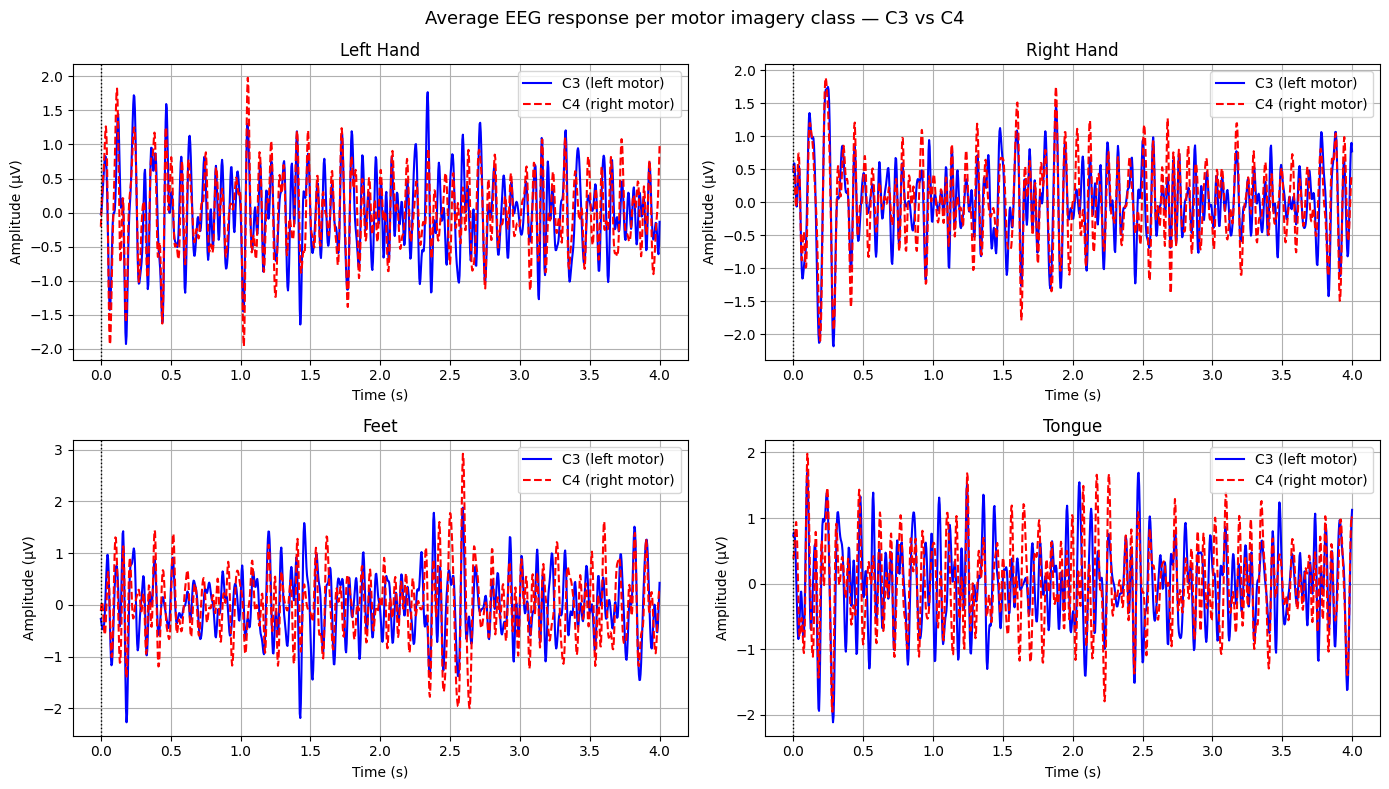

In [8]:
# plot average signal for each class on C3 and C4
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

classes = ['left_hand', 'right_hand', 'feet', 'tongue']
colors = ['blue', 'red', 'green', 'orange']
times = epochs.times

for idx, (cls, color) in enumerate(zip(classes, colors)):
    # get data for this class, only C3 and C4
    data = epochs[cls].get_data(picks=['EEG-C3', 'EEG-C4'])
    
    # average across trials
    mean_c3 = data[:, 0, :].mean(axis=0) * 1e6  # convert to µV
    mean_c4 = data[:, 1, :].mean(axis=0) * 1e6

    axes[idx].plot(times, mean_c3, label='C3 (left motor)', color='blue')
    axes[idx].plot(times, mean_c4, label='C4 (right motor)', 
                   color='red', linestyle='--')
    axes[idx].set_title(f'{cls.replace("_", " ").title()}')
    axes[idx].set_xlabel('Time (s)')
    axes[idx].set_ylabel('Amplitude (µV)')
    axes[idx].legend()
    axes[idx].grid(True)
    axes[idx].axvline(x=0, color='black', linewidth=1, linestyle=':')

plt.suptitle('Average EEG response per motor imagery class — C3 vs C4', 
             fontsize=13)
plt.tight_layout()
plt.show()